230316
EE708 Assignment 5
QUESTION 7

Run 1
Weights: [0.39641921 0.18371322 1.27480671]
Accuracy: 100.00%


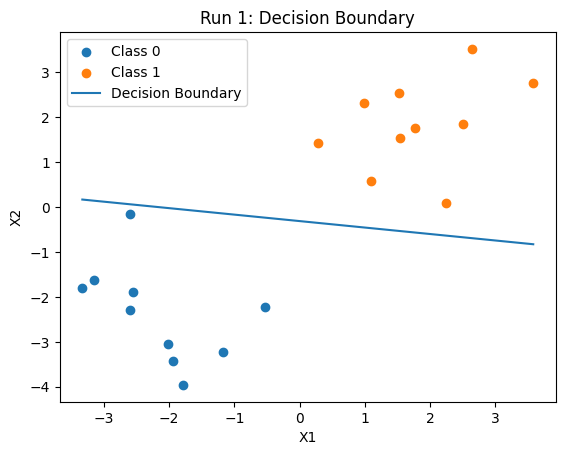

Run 2
Weights: [0.3346094  0.02157928 1.74304055]
Accuracy: 95.00%


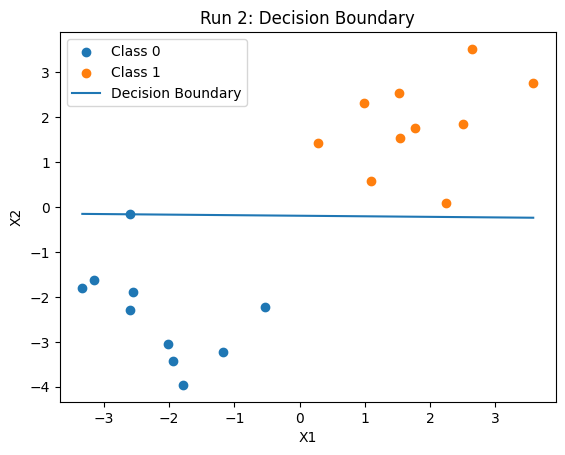

Run 3
Weights: [-0.84337839 -0.06927334  1.53841704]
Accuracy: 90.00%


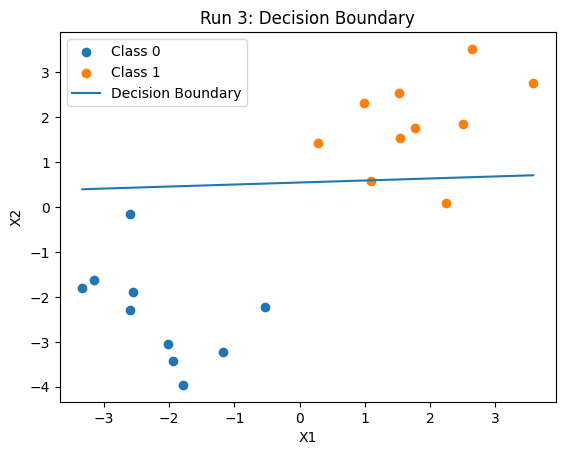

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv("A5_P1.csv")

X = df[['X1', 'X2']].values
y = df['y'].values

y = y.astype(int)
y = np.where(y == -1, 0, y)

# Add bias term
X = np.c_[np.ones(X.shape[0]), X]


def step(z):
    return np.where(z >= 0, 1, 0)


def train_perceptron(X, y, lr=0.01, epochs=20):
    w = np.random.randn(X.shape[1])  

    for epoch in range(epochs):
        indices = np.random.permutation(len(X))  # shuffle (SGD)

        for i in indices:
            z = np.dot(w, X[i])
            y_pred = step(z)

            # update rule
            w = w + lr * (y[i] - y_pred) * X[i]

    return w


def compute_accuracy(X, y, w):
    preds = step(np.dot(X, w))
    return np.mean(preds == y)


def plot_decision_boundary(X, y, w, title):
    plt.figure()

    class0 = X[y == 0]
    class1 = X[y == 1]

    plt.scatter(class0[:,1], class0[:,2], label="Class 0")
    plt.scatter(class1[:,1], class1[:,2], label="Class 1")

    x_vals = np.linspace(X[:,1].min(), X[:,1].max(), 100)

    if abs(w[2]) > 1e-6:
        y_vals = -(w[0] + w[1]*x_vals) / w[2]
        plt.plot(x_vals, y_vals, label="Decision Boundary")

    plt.xlabel("X1")
    plt.ylabel("X2")
    plt.title(title)
    plt.legend()
    plt.show()


runs = 3

for i in range(runs):
    w = train_perceptron(X, y)

    acc = compute_accuracy(X, y, w)

    print(f"Run {i+1}")
    print("Weights:", w)
    print(f"Accuracy: {acc*100:.2f}%")

    plot_decision_boundary(X, y, w, f"Run {i+1}: Decision Boundary")


* The dataset appears to be linearly separable, as the perceptron achieves near-perfect classification.
* The dataset is shuffled at each epoch, implementing stochastic gradient descent.
* Due to limited iterations (20), some runs do not fully converge.

QUESTION 8

In [4]:
!pip install scikit-learn

  Using cached scipy-1.17.1-cp312-cp312-win_amd64.whl.metadata (60 kB)
Using cached scipy-1.17.1-cp312-cp312-win_amd64.whl (36.5 MB)


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ehtim 1.2.10 requires astropy>=5.0.4, which is not installed.
photutils 2.2.0 requires astropy>=5.3, which is not installed.

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


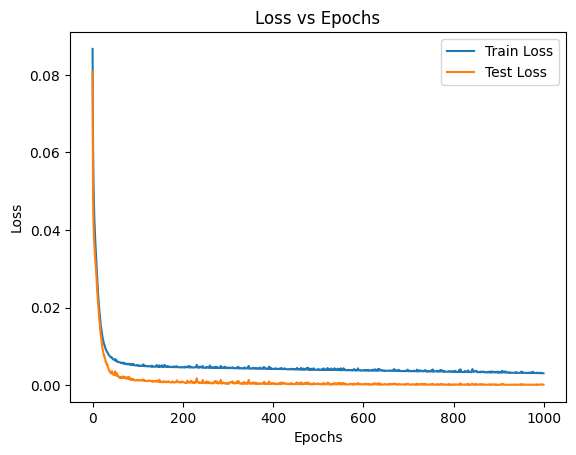

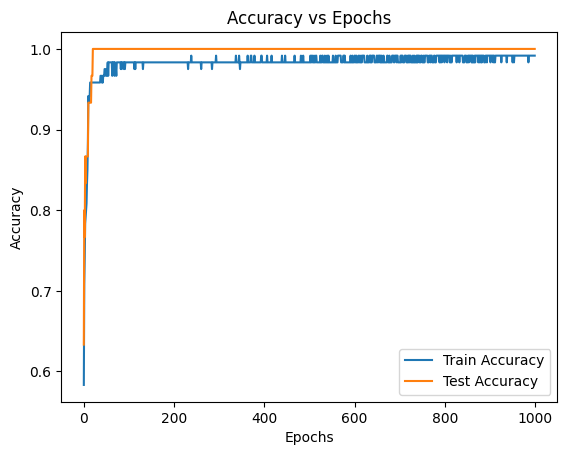

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


iris = load_iris()
X = iris.data
y = iris.target

def one_hot(y, num_classes):
    y_onehot = np.zeros((len(y), num_classes))
    y_onehot[np.arange(len(y)), y] = 1
    return y_onehot

y = one_hot(y, 3)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


input_size = 4
hidden_size = 5
output_size = 3

np.random.seed(42)
W1 = np.random.randn(input_size, hidden_size)
b1 = np.zeros((1, hidden_size))
W2 = np.random.randn(hidden_size, output_size)
b2 = np.zeros((1, output_size))

def tanh(x):
    return np.tanh(x)

def tanh_deriv(x):
    return 1 - np.tanh(x)**2

def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)


def mse(y_true, y_pred):
    return 0.5 * np.mean((y_true - y_pred)**2)

def accuracy(y_true, y_pred):
    return np.mean(np.argmax(y_true, axis=1) == np.argmax(y_pred, axis=1))

# Training (SGD)
lr = 0.01
epochs = 1000

train_loss, test_loss = [], []
train_acc, test_acc = [], []

for epoch in range(epochs):
    indices = np.random.permutation(len(X_train))

    for i in indices:
        x = X_train[i:i+1]
        y_true = y_train[i:i+1]

        # ---- Forward pass ----
        z1 = x @ W1 + b1
        a1 = tanh(z1)

        z2 = a1 @ W2 + b2
        y_pred = softmax(z2)

        # ---- Backward pass ----
        dL_dy = (y_pred - y_true)

        # Output layer
        dW2 = a1.T @ dL_dy
        db2 = dL_dy

        # Hidden layer
        d_hidden = (dL_dy @ W2.T) * tanh_deriv(z1)
        dW1 = x.T @ d_hidden
        db1 = d_hidden

        # ---- Update ----
        W2 -= lr * dW2
        b2 -= lr * db2
        W1 -= lr * dW1
        b1 -= lr * db1

    # ---- Metrics ----
    # Train
    z1 = X_train @ W1 + b1
    a1 = tanh(z1)
    z2 = a1 @ W2 + b2
    y_train_pred = softmax(z2)

    # Test
    z1_t = X_test @ W1 + b1
    a1_t = tanh(z1_t)
    z2_t = a1_t @ W2 + b2
    y_test_pred = softmax(z2_t)

    train_loss.append(mse(y_train, y_train_pred))
    test_loss.append(mse(y_test, y_test_pred))
    train_acc.append(accuracy(y_train, y_train_pred))
    test_acc.append(accuracy(y_test, y_test_pred))

plt.figure()
plt.plot(train_loss, label="Train Loss")
plt.plot(test_loss, label="Test Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss vs Epochs")
plt.legend()
plt.show()


plt.figure()
plt.plot(train_acc, label="Train Accuracy")
plt.plot(test_acc, label="Test Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epochs")
plt.legend()
plt.show()

* The model achieves near-perfect accuracy on both training and testing data, indicating that the Iris dataset is linearly and non-linearly separable with a simple neural network.

* Minor fluctuations in training accuracy are due to stochastic gradient updates.